# Data Pipelines & Data Analytics Lifecycle
# Forecasting the Wind Power Production in Orkney


**Dependencies**

If you've just created this workspace, install mlflow by typing the command below in the Terminal. If you already did this in a previous session, there is no need to install it again.

```
pip install mlflow
```

Now let's import all libraries necessary for this project.
The first time you will run a cell in this notebook, a dialogue box will appear asking if you want to Install/enable suggested extentions: python and jupyter. Go ahead and once that is finished select the created kernel.

In [2]:
import mlflow

# You will probably need these
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline

# This are for example purposes. You may discard them if you don't use them.
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from mlflow.models import infer_signature
from urllib.parse import urlparse
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate


### TODO -> HERE YOU CAN ADD ANY OTHER LIBRARIES YOU MAY NEED ###



## Data exploration



In [3]:
# Load DF's
power_df = pd.read_csv('data/power.csv', parse_dates=["time"], index_col="time")
wind_df = pd.read_csv('data/weather.csv', parse_dates=["time"], index_col="time")

In [4]:
# Drop empty columns and remove unnecessary features
power_df = power_df.dropna()
wind_df = wind_df.dropna()
power_df = power_df.drop(columns=['ANM', 'Non-ANM'])
wind_df = wind_df.drop(columns = ['Lead_hours', 'Source_time'])

In [5]:
# Sort by 'time' (required for merge_asof)
power_df = power_df.sort_values('time')
wind_df = wind_df.sort_values('time')

# Perform "as-of" join
# 'backward' matches each power entry with the weather recorded AT or BEFORE that time.
merged_df = pd.merge_asof(power_df, wind_df, on='time', direction='backward')

upsampled_df = merged_df.dropna()

### Understanding the data: EDA

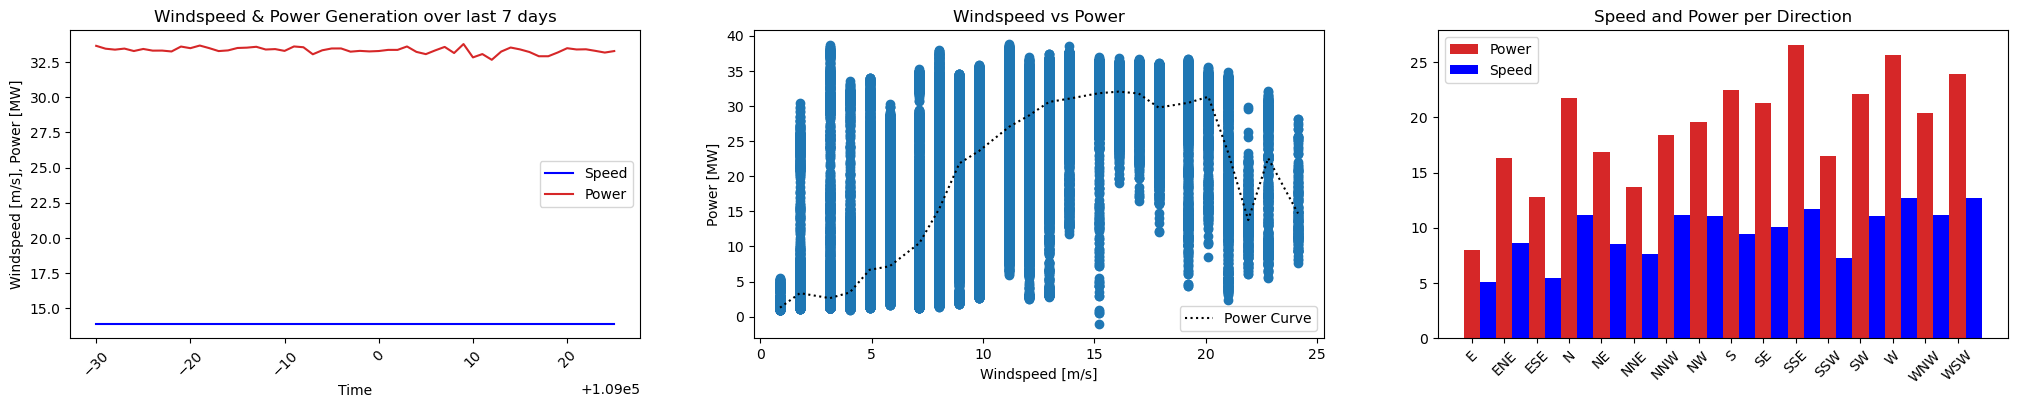

In [6]:
# Subplots
fig, ax = plt.subplots(1,3, figsize=(25,4))

# Speed and Power for the last 7 days
ax[0].plot(upsampled_df["Speed"].tail(int(7*24/3)), label="Speed", color="blue") # Since the datasets are joined every three hours, we need the last 7 days times 24 hours diveded by 3 hours
ax[0].plot(upsampled_df["Total"].tail(int(7*24/3)), label="Power", color="tab:red") # Since the datasets are joined every three hours, we need the last 7 days times 24 hours diveded by 3 hours
ax[0].set_title("Windspeed & Power Generation over last 7 days")
ax[0].set_xlabel("Time")
ax[0].tick_params(axis='x', labelrotation = 45)
ax[0].set_ylabel("Windspeed [m/s], Power [MW]")
ax[0].legend()

# Speed vs Total (Power Curve nature)
ax[1].scatter(upsampled_df["Speed"], upsampled_df["Total"])
power_curve = upsampled_df.groupby("Speed").median(numeric_only=True)["Total"]
ax[1].plot(power_curve.index, power_curve.values, "k:", label="Power Curve")
ax[1].legend()
ax[1].set_title("Windspeed vs Power")
ax[1].set_ylabel("Power [MW]")
ax[1].set_xlabel("Windspeed [m/s]")

# Speed and Power per Wind Direction
wind_grouped_by_direction = upsampled_df.groupby("Direction").mean(numeric_only=True).reset_index()
bar_width = 0.5
x = np.arange(len(wind_grouped_by_direction.index))

ax[2].bar(x, wind_grouped_by_direction.Total, width=0.5, label="Power", color="tab:red")
ax[2].bar(x + bar_width, wind_grouped_by_direction.Speed, width=0.5, label="Speed", color="blue")
ax[2].legend()
ax[2].set_xticks(x)
ax[2].set_xticklabels(wind_grouped_by_direction.Direction)
ax[2].tick_params(axis='x', labelrotation = 45)
ax[2].set_title("Speed and Power per Direction");

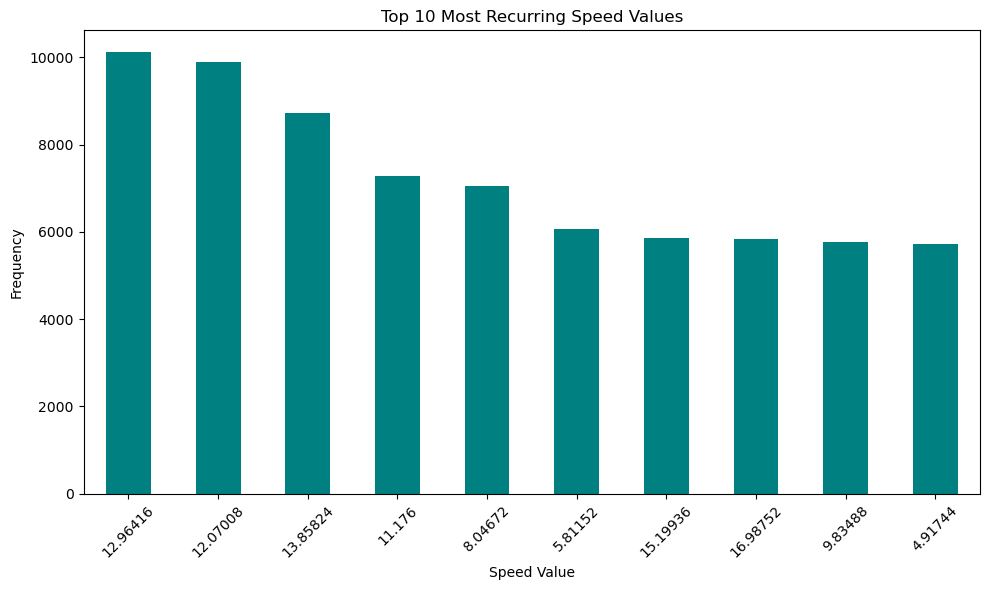

In [7]:
speed_counts = upsampled_df['Speed'].value_counts().head(10)
plt.figure(figsize=(10, 6))
speed_counts.plot(kind='bar', color='teal')
plt.title('Top 10 Most Recurring Speed Values')
plt.xlabel('Speed Value')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('speed_freq.png')

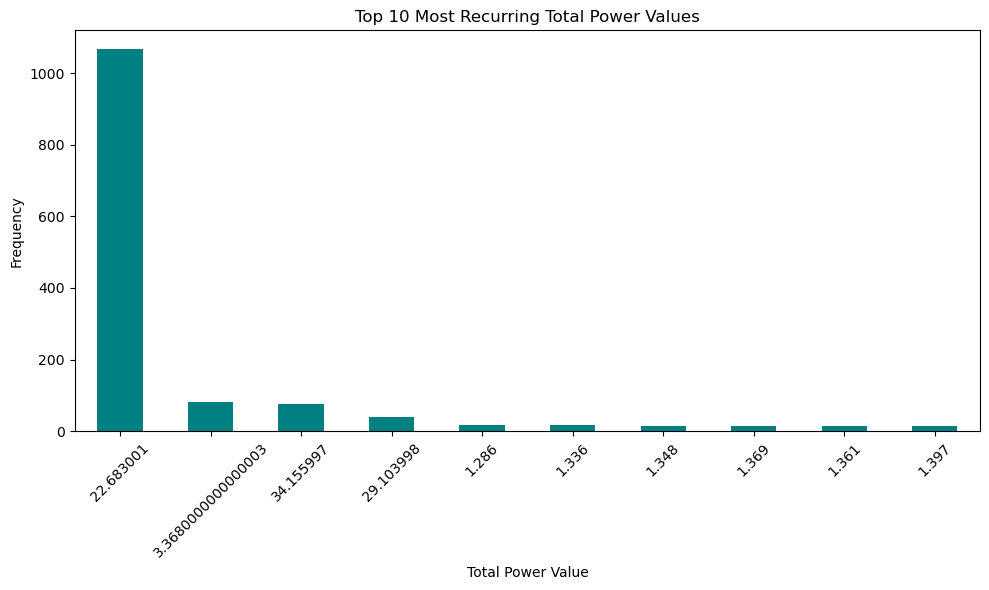

In [8]:
speed_counts = upsampled_df['Total'].value_counts().head(10)
plt.figure(figsize=(10, 6))
speed_counts.plot(kind='bar', color='teal')
plt.title('Top 10 Most Recurring Total Power Values')
plt.xlabel('Total Power Value')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('speed_freq.png')

<Figure size 800x600 with 0 Axes>

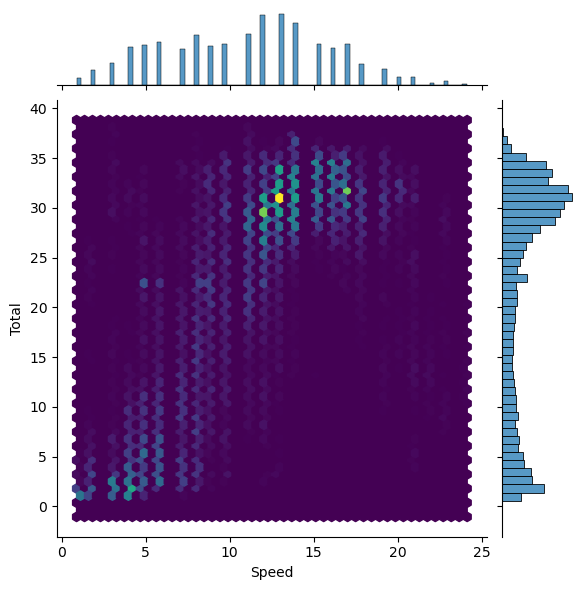

In [9]:
# 3. Correlation/Joint Plot to see recurring pairs
plt.figure(figsize=(8, 6))
sns.jointplot(x='Speed', y='Total', data=upsampled_df, kind='hex', cmap='viridis')
plt.savefig('speed_total_joint.png')

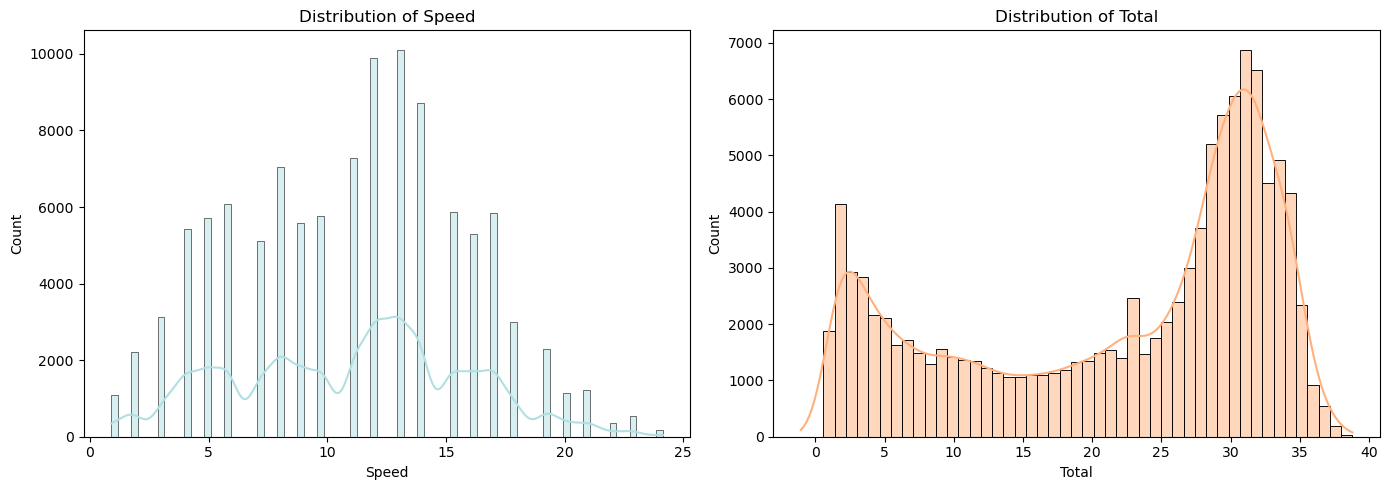

In [10]:
# 1. Distribution of Speed and Total
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(upsampled_df['Speed'], kde=True, ax=axes[0], color='#B0E0E2')
axes[0].set_title('Distribution of Speed')
sns.histplot(upsampled_df['Total'], kde=True, ax=axes[1], color='#FFB07C')
axes[1].set_title('Distribution of Total')
plt.tight_layout()
plt.savefig('distribution.png')

In [11]:
df_engineered = upsampled_df
df_engineered = df_engineered.drop(columns = 'time')


Then apply a tail cut

Execute a conservative 15% split on the data itself

In [12]:
test_size = int(len(df_engineered)*0.15)
train_size = len(df_engineered) - test_size

trainingDF = df_engineered.iloc[:train_size]
finalTestDF = df_engineered.iloc[train_size:]

print(f"Training set: {len(trainingDF)} rows")
print(f"Test set: {len(finalTestDF)} rows")

Training set: 92604 rows
Test set: 16341 rows


___PETER PIPELINE IDEAS___

In [13]:

class WindDirectionEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, column_name='Direction'):
        self.column_name = column_name
        self.mapping = {
            'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
            'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5, 
            'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5, 
            'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
        }

    def fit(self, X, y=None):
        # Nothing to learn from the data here, so we just return self
        return self

    def transform(self, X):
        # Works on a copy to prevent modifying the original dataframe
        X = X.copy()
        # 1. Checks if the data has already been transformed
        if 'dir_sin' in X.columns and 'dir_cos' in X.columns:
            # If the original column is still there, drop it; otherwise just return X
            if self.column_name in X.columns:
                return X.drop(columns=[self.column_name])
            return X
        
        # 2. Safety check: does the source column actually exist?
        if self.column_name not in X.columns:
            raise KeyError(f"The column '{self.column_name}' is missing from the input features.")

        # 3. Perform mapping and cyclical encoding
        deg = X[self.column_name].map(self.mapping).fillna(0)
        X['dir_sin'] = np.sin(2 * np.pi * deg / 360)
        X['dir_cos'] = np.cos(2 * np.pi * deg / 360)
        
        # 4. Drop the original categorical column
        return X.drop(columns=[self.column_name])


In [14]:
regressionTree_pipeline = Pipeline([
    ('Wind_Encoding', WindDirectionEncoder(column_name='Direction')),
    ('imputer', SimpleImputer(strategy='median')), # Preprocessing
    ('regressor', DecisionTreeRegressor(max_depth=5, random_state=42)) # Model
])

In [15]:
# 2. Split your data (Standard practice)
y = trainingDF['Total']
X = trainingDF.drop('Total', axis=1)


# Split the data so we can test how well our model performs in unseen data
X_train, X_test, y_train, y_test = train_test_split(X, y) # -> You might want to use another split method

# Train our model
regressionTree_pipeline.fit(X_train, y_train)

# Evaluate the model, using MAE as a metric
mae = mean_absolute_error(regressionTree_pipeline.predict(X_test), y_test)
print(mae)

4.242370144158635


Predictions made on models which assume time seriess is not important.

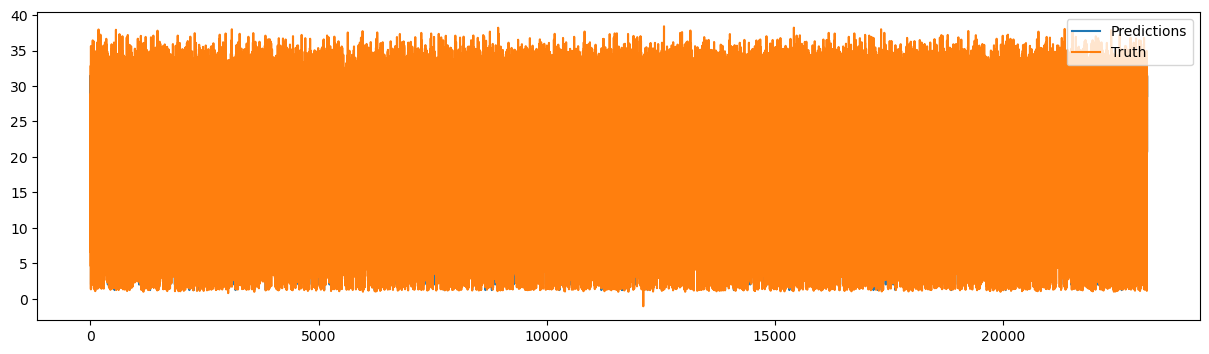

In [16]:
# Doesn't work on the upsamped data because it scramble 100,000 data points
predictions = regressionTree_pipeline.predict(X_test)

plt.figure(figsize=(15, 4))
plt.plot(np.arange(len(predictions)), predictions, label="Predictions")
plt.plot(np.arange(len(y_test)), y_test, label="Truth")
plt.legend()
plt.show()

##Acounting for Time-Series##

In [17]:
regressionTree_pipeline_TS = Pipeline([
    ('Wind_Encoding', WindDirectionEncoder(column_name='Direction')),
    ('imputer', SimpleImputer(strategy='median')), # Preprocessing
    ('regressor', DecisionTreeRegressor(max_depth=4, min_samples_split=15, min_samples_leaf=18, max_features= None, random_state=42,)) # Model
])


In [18]:
# 1. Prepare Data
trainingDF = trainingDF.dropna().sort_index()
y_ts = trainingDF['Total']
X_ts = trainingDF.drop('Total', axis=1)

# 2. Define TSS
tss = TimeSeriesSplit(n_splits=5)
mae_scores = []

# 3. Implementation of Cross-Validation
for train_index, test_index in tss.split(X_ts):
    # Split the data for this specific fold
    X_train_fold, X_test_fold = X_ts.iloc[train_index], X_ts.iloc[test_index]
    y_train_fold, y_test_fold = y_ts.iloc[train_index], y_ts.iloc[test_index]
    
    # Train the model on THIS fold
    regressionTree_pipeline_TS.fit(X_train_fold, y_train_fold)
    
    # Evaluate THIS fold
    preds = regressionTree_pipeline_TS.predict(X_test_fold)
    fold_mae = mean_absolute_error(y_test_fold, preds)
    mae_scores.append(fold_mae)
    
    print(f"Fold MAE: {fold_mae}")

# 4. Final Result
print(f"Average Time-Series CV MAE: {np.mean(mae_scores)}")

Fold MAE: 4.647693137011286
Fold MAE: 3.7776513066538326
Fold MAE: 5.897067526264
Fold MAE: 5.9368878517185255
Fold MAE: 5.660048945311671
Average Time-Series CV MAE: 5.183869753391863


In [19]:
def objective(trial):
    # 1. Suggest ranges for Decision Tree hyperparameters
    # We use integers for depth and split constraints
    max_depth = trial.suggest_int('max_depth', 2, 32)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', [None, 'sqrt', 'log2'])
    
    # 2. Update your pipeline (Assuming your regressor step is named 'regressor')
    regressionTree_pipeline_TS.set_params(
        regressor__max_depth=max_depth,
        regressor__min_samples_split=min_samples_split,
        regressor__min_samples_leaf=min_samples_leaf,
        regressor__max_features=max_features
    )
    
    # 3. Use your existing TimeSeriesSplit (tss)
    # Scoring remains 'neg_mean_absolute_error' to minimize the positive MAE
    score = cross_val_score(regressionTree_pipeline_TS, X_ts, y_ts, cv=tss, scoring='neg_mean_absolute_error', n_jobs=-1)
    mae = -score.mean()
    
    return mae

# 4. Create a study and optimize
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=500) # Trees are faster than SVR; 100 trials is a good start

print(f"Best parameters: {study.best_params}")
print(f"Best MAE: {study.best_value}")

[I 2026-03-17 19:21:02,892] A new study created in memory with name: no-name-cb2a9f3b-ef7e-4d8a-826b-0bd77597e65c
[I 2026-03-17 19:21:06,824] Trial 0 finished with value: 5.541434393694678 and parameters: {'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 0 with value: 5.541434393694678.
[I 2026-03-17 19:21:09,455] Trial 1 finished with value: 6.013087995331884 and parameters: {'max_depth': 16, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 5.541434393694678.
[I 2026-03-17 19:21:11,999] Trial 2 finished with value: 6.059622079510069 and parameters: {'max_depth': 21, 'min_samples_split': 15, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 5.541434393694678.
[I 2026-03-17 19:21:14,213] Trial 3 finished with value: 6.534143800240727 and parameters: {'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 15, 'max_features': 'sqrt'}. Best is trial 0 with 

Best parameters: {'max_depth': 4, 'min_samples_split': 8, 'min_samples_leaf': 12, 'max_features': None}
Best MAE: 5.183869753391863


Anaconda PowerShell Prompt

conda activate ml

mlflow server --host 127.0.0.1 --port 5000

In [21]:
# Start an MLflow run
mlflow.sklearn.autolog() # This is to help us track scikit learn metrics.
mlflow.set_tracking_uri("http://127.0.0.1:5000") # We set the MLFlow UI to display in our local host.

# Setup Time-Series Cross-Validation
# Ensures not to predict the past using the future
tscv = TimeSeriesSplit(n_splits=5)

# Set the experiment and run name
experiment_name = "RegressionTree_TS" # Think how to best organise experiments - for example by model type
run_name = "RT_TS_100K" # Give explicit names 

mlflow.set_experiment(experiment_name)

with mlflow.start_run(run_name=run_name) as run:
    
    # 2. Run Cross-Validation
    # autolog() will catch the estimator parameters and CV results
    cv_results = cross_validate(
        regressionTree_pipeline_TS, 
        X_ts, 
        y_ts, 
        cv=tscv, 
        scoring='neg_mean_absolute_error',
        return_train_score=True
    )

    # 3. Calculate Mean MAE (converting back from negative)
    mae_scores = -cv_results['test_score']
    mean_mae = np.mean(mae_scores)
    std_mae = np.std(mae_scores)

    # 4. Log summary metrics manually for easy UI comparison
    mlflow.log_metric("mean_MAE", mean_mae)
    mlflow.log_metric("std_MAE", std_mae)
    
    # 5. Final Fit (optional: fit on all data to save the final model)
    regressionTree_pipeline_TS.fit(X_ts, y_ts)
    mlflow.sklearn.log_model(regressionTree_pipeline_TS, "model")

    print(f"Cross-Validated MAE: {mean_mae:.4f} (+/- {std_mae:.4f})")

2026/03/17 19:24:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/17 19:24:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/17 19:25:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

Cross-Validated MAE: 5.2447 (+/- 0.7941)
🏃 View run RT_TS_100K at: http://127.0.0.1:5000/#/experiments/6/runs/8bfce8c995fb42c9b6888183cf66edb9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6


Now have a look at the *Explorer* tab on the left and notice the newly created files and folders: 
- `mlflow.db` - a database containing metadata regarding experiments, runs, and parameters that you logged
- `mlartifacts/` folders
    - each folder will correspond to a run
    - the `models` folder contains data about the logged models, such as the envinroment file, a .pkl file containing the model, and a MLmodel complete description of the model; have a look at each of those

##Preprocessing FUTURE FILES##

In [ ]:
y_final = finalTestDF['Total']
X_final = finalTestDF.drop('Total', axis=1)

In [ ]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")

In [ ]:
#Load final model
model_name = "RT_TS_100K"
model_version = 3

model_uri = f"models:/{model_name}/{model_version}"
model = mlflow.pyfunc.load_model(model_uri=model_uri)

#Run final experiment
experiment_name = "Final_MODELS"
mlflow.set_experiment(experiment_name)

# 4. Run Inference and Log Metrics
# We start a new run specifically for this evaluation
with mlflow.start_run(run_name="RT_FINAL"):
    
    # Generate predictions on the unseen data
    predictions = model.predict(X_final)
    
    # Calculate Standard Metrics
    mae = mean_absolute_error(y_final, predictions)
    r2 = r2_score(y_final, predictions)
    
    # Calculate Adjusted R-squared
    # n = number of samples, k = number of features
    n = X_final.shape[0]
    k = X_final.shape[1]
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

    # Log metrics to MLflow
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("R2", r2)
    mlflow.log_metric("Adjusted_R2", adj_r2)

    print(f"Inference complete. Adjusted R2: {adj_r2:.4f}")

Inference complete. Adjusted R2: 0.7752
🏃 View run RT_FINAL at: http://127.0.0.1:5000/#/experiments/7/runs/6fe35dc3b2704520acdc7ee884668b5a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


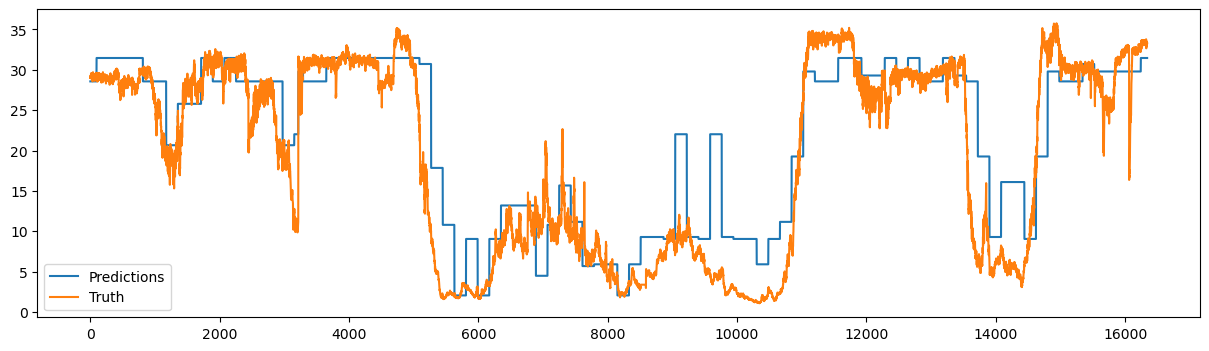

In [ ]:
predictions =regressionTree_pipeline.predict(X_final)

plt.figure(figsize=(15, 4))
plt.plot(np.arange(len(predictions)), predictions, label="Predictions")
plt.plot(np.arange(len(y_final)), y_final, label="Truth")
plt.legend()
plt.show()

In [ ]:
future_df = pd.read_csv("data/future.csv")
future_df["time"] = pd.to_datetime(future_df["time"], utc=True)
future_df["Source_time"] = pd.to_datetime(future_df["Source_time"], unit="s", utc=True)
future_df.drop(columns=['time','Lead_hours','Source_time'])

,Direction,Speed
0,SE,15.19936
1,SE,16.09344
2,SE,16.98752
3,SSE,16.09344
4,SSE,12.96416
5,SSE,8.04672
6,SSE,8.94080
7,SE,11.17600
8,SSE,12.07008
9,SSW,8.94080


In [29]:
model_name = "RT_TS_100K"
model_version = 3

model_uri = f"models:/{model_name}/{model_version}"
model = mlflow.pyfunc.load_model(model_uri=model_uri)

X_forecast = future_df
predictions = model.predict(X_forecast)

predictions_df = future_df[["Speed"]].copy()
predictions_df["Predicted_Power"] = predictions

print(predictions_df.head())

predictions_df

2026/03/15 21:05:32 WARNING mlflow.models.utils: Found extra inputs in the model input that are not defined in the model signature: `['time', 'Source_time', 'Lead_hours']`. These inputs will be ignored.


      Speed  Predicted_Power
0  15.19936        30.663953
1  16.09344        30.663953
2  16.98752        30.663953
3  16.09344        30.663953
4  12.96416        30.663953


,Speed,Predicted_Power
0,15.19936,30.663953
1,16.09344,30.663953
2,16.98752,30.663953
3,16.09344,30.663953
4,12.96416,30.663953
5,8.04672,18.198144
6,8.94080,26.882688
7,11.17600,24.210046
8,12.07008,26.731976
9,8.94080,26.882688


Worked in PowerShell for Serving here is how to run things in powershell

In [ ]:
powershell: $env:MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"

SyntaxError: invalid syntax (38145292.py, line 1)

In [ ]:
powershell: mlflow models serve -m "models:/RT_TS_100K/3" --port 5001 --host 127.0.0.1 --env-manager local

In [ ]:
powershell:

curl.exe -X POST "http://127.0.0.1:5001/invocations" -H "Content-Type: application/json" --% -d "{\"dataframe_split\": {\"columns\": [\"Total\", \"Speed\", \"Direction\"], \"data\": [[30, 12, \"NNE\"]]}}"

## Packaging your project

In [30]:
import nbformat
from nbconvert import PythonExporter

# Load your notebook
with open('exploration_upsample_Pete.ipynb') as f:
    nb = nbformat.read(f, as_version=4)

# Export to Python
exporter = PythonExporter()
source, _ = exporter.from_notebook_node(nb)

# Save to .py file
with open('exploration_upsample_Pete.py', 'w') as f:
    f.write(source)